EXPERIMENT-1

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("TvMarketing.csv")

In [ ]:
# a) Importing Data & Understanding Structure
#Display first 5 rows
print("First 5 rows:\n", df.head())
#Dataset information
print("\nDataset Info:")
print(df.info())
#Statistical summary
print("\nStatistical Summary:")
print(df.describe())

First 5 rows:
       TV  Sales
0  230.1   22.1
1   44.5   10.4
2   17.2    9.3
3  151.5   18.5
4  180.8   12.9

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB
None

Statistical Summary:
               TV       Sales
count  200.000000  200.000000
mean   147.042500   14.022500
std     85.854236    5.217457
min      0.700000    1.600000
25%     74.375000   10.375000
50%    149.750000   12.900000
75%    218.825000   17.400000
max    296.400000   27.000000


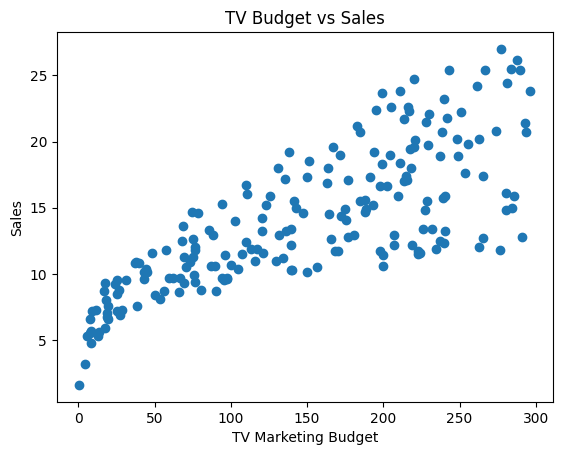

In [ ]:
# b) Visualising Data Using Plot
plt.scatter(df['TV'], df['Sales'])
plt.xlabel("TV Marketing Budget")
plt.ylabel("Sales")
plt.title("TV Budget vs Sales")
plt.show()

In [ ]:
#c) Splitting Data (80:20)

# Predictor and target
X = df[['TV']]     # Independent variable
y = df['Sales']    # Dependent variable

# Train-test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (160, 1)
Testing Data Shape: (40, 1)


In [ ]:
# d) Train Simple Linear Regression Model

model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Get parameters
b0 = model.intercept_
b1 = model.coef_[0]

print("Intercept (b0):", b0)
print("Slope (b1):", b1)

Intercept (b0): 7.119638430592953
Slope (b1): 0.046529733705443346


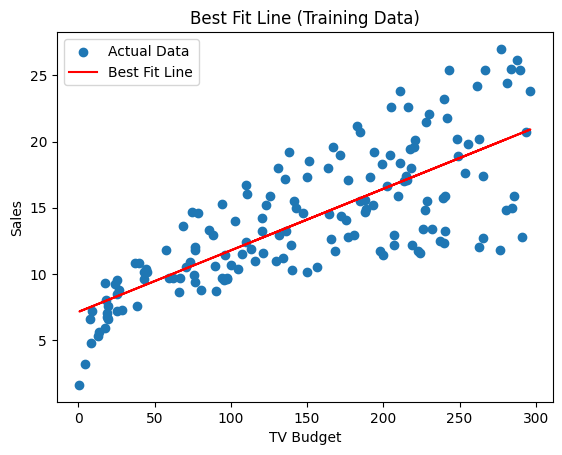

In [ ]:
# e) Visualize Best Fit Line

plt.scatter(X_train, y_train, label="Actual Data")
plt.plot(X_train, model.predict(X_train), color='red', label="Best Fit Line")
plt.xlabel("TV Budget")
plt.ylabel("Sales")
plt.title("Best Fit Line (Training Data)")
plt.legend()
plt.show()

In [ ]:
#f) Actual vs Predicted Sales

# Predictions
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head())

   Actual  Predicted
0    16.9  14.717944
1    22.4  16.211548
2    21.4  20.748197
3     7.3   7.664036
4    24.7  17.370139


In [ ]:
#g) Compute RMSE and R²

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 3.194472431998898
R² Score: 0.6766954295627076


EXPERIMENT - 2

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
df = pd.read_csv("DATA.csv")

# Display first 5 rows
print("First 5 rows:\n", df.head())

# Dataset info
print("\nDataset Info:")
print(df.info())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())


First 5 rows:
           Car       Model  Volume  Weight  CO2  Unnamed: 5
0      Toyota        Aygo    1000     790   99         NaN
1  Mitsubishi  Space Star    1200    1160   95         NaN
2       Skoda      Citigo    1000     929   95         NaN
3        Fiat         500     900     865   90         NaN
4        Mini      Cooper    1500    1140  105         NaN

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Car         36 non-null     object 
 1   Model       36 non-null     object 
 2   Volume      36 non-null     int64  
 3   Weight      36 non-null     int64  
 4   CO2         36 non-null     int64  
 5   Unnamed: 5  0 non-null      float64
dtypes: float64(1), int64(3), object(2)
memory usage: 1.8+ KB
None

Statistical Summary:
            Volume       Weight         CO2  Unnamed: 5
count    36.000000    36.000000   36.0000

Correlation Matrix:
           Volume    Weight       CO2
Volume  1.000000  0.753537  0.592082
Weight  0.753537  1.000000  0.552150
CO2     0.592082  0.552150  1.000000


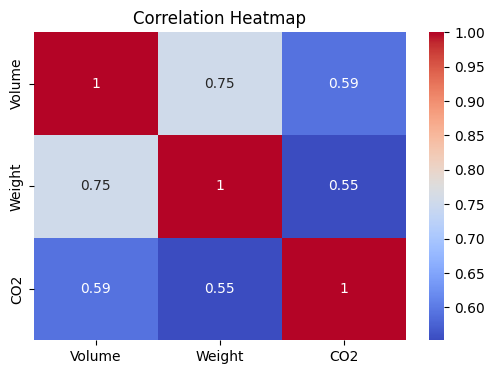

In [ ]:
# b) Correlation Coefficient + Heatmap
# Calculate correlation matrix
corr = df[['Volume', 'Weight', 'CO2']].corr()

print("Correlation Matrix:\n", corr)

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

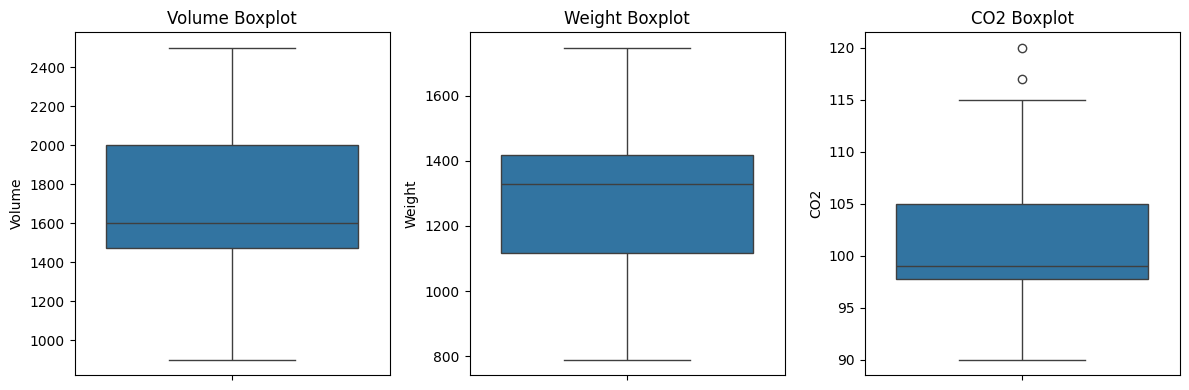

In [ ]:
#c) Check Outliers using Boxplot
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(y=df['Volume'])
plt.title("Volume Boxplot")

plt.subplot(1,3,2)
sns.boxplot(y=df['Weight'])
plt.title("Weight Boxplot")

plt.subplot(1,3,3)
sns.boxplot(y=df['CO2'])
plt.title("CO2 Boxplot")

plt.tight_layout()
plt.show()

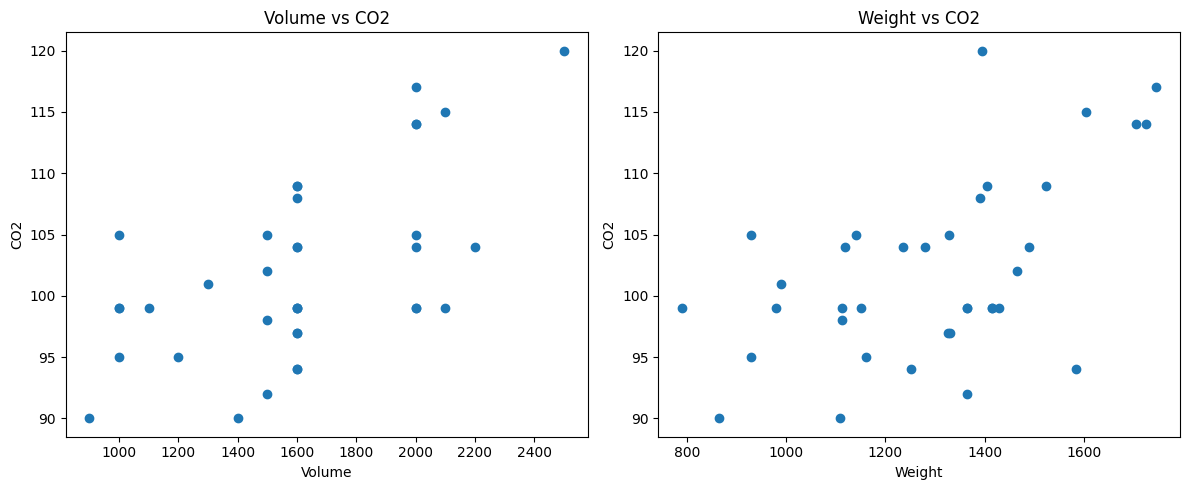

In [ ]:
#d) Visualize CO2 vs Volume & Weight
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(df['Volume'], df['CO2'])
plt.xlabel("Volume")
plt.ylabel("CO2")
plt.title("Volume vs CO2")

plt.subplot(1,2,2)
plt.scatter(df['Weight'], df['CO2'])
plt.xlabel("Weight")
plt.ylabel("CO2")
plt.title("Weight vs CO2")

plt.tight_layout()
plt.show()

In [ ]:
#e) Train Multiple Linear Regression Model (80:20 Split)
# Independent and dependent variables
X = df[['Volume', 'Weight']]
y = df['CO2']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

Training Shape: (28, 2)
Testing Shape: (8, 2)


LinearRegression()

Intercept (b0): 84.21502006695282
Weights (b1, b2): [0.00428741 0.00804928]


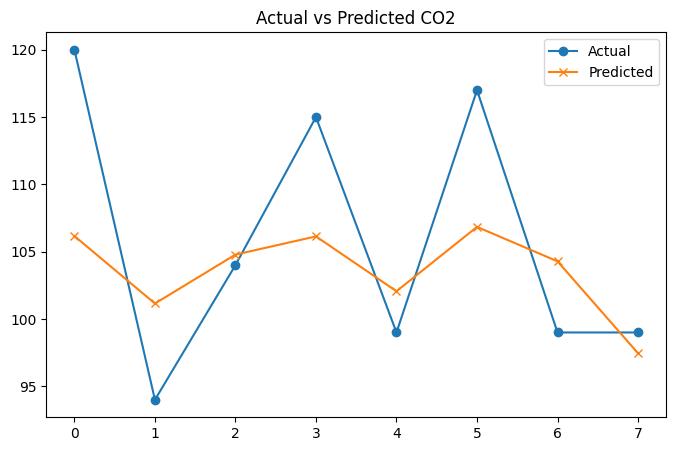

In [ ]:
#f) Calculate Weights & Intercept + True vs Predicted Plot
# Model parameters
intercept = model.intercept_
weights = model.coef_

print("Intercept (b0):", intercept)
print("Weights (b1, b2):", weights)

# Prediction
y_pred = model.predict(X_test)

# True vs Predicted line chart
plt.figure(figsize=(8,5))
plt.plot(range(len(y_test)), y_test.values, label="Actual", marker='o')
plt.plot(range(len(y_pred)), y_pred, label="Predicted", marker='x')
plt.legend()
plt.title("Actual vs Predicted CO2")
plt.show()

In [ ]:
#g) Calculate MAE, MSE, RMSE
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 6.335639624274503
Mean Squared Error (MSE): 58.07928583657771
Root Mean Squared Error (RMSE): 7.620976698335832


# EXPERIMENT-3


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve

# Load dataset
df = pd.read_csv("advertising.csv")

# Display first 5 rows
print("First 5 rows:\n", df.head())

# Dataset info
print("\nDataset Info:")
print(df.info())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())


First 5 rows:
    Daily Time Spent on Site  Age  Area Income  Daily Internet Usage  \
0                     68.95   35     61833.90                256.09   
1                     80.23   31     68441.85                193.77   
2                     69.47   26     59785.94                236.50   
3                     74.15   29     54806.18                245.89   
4                     68.37   35     73889.99                225.58   

                           Ad Topic Line            City  Male     Country  \
0     Cloned 5thgeneration orchestration     Wrightburgh     0     Tunisia   
1     Monitored national standardization       West Jodi     1       Nauru   
2       Organic bottom-line service-desk        Davidton     0  San Marino   
3  Triple-buffered reciprocal time-frame  West Terrifurt     1       Italy   
4          Robust logistical utilization    South Manuel     0     Iceland   

             Timestamp  Clicked on Ad  
0  2016-03-27 00:53:11              0  
1  2016-0

In [ ]:
#b) Exploratory Data Analysis (EDA)
#(1)Check Missing / Null Values
print("Missing Values:\n", df.isnull().sum())
#If missing values exist:
df = df.dropna()
#Data Transformation (Drop non-numeric columns if needed)
df = df.drop(['Ad Topic Line', 'City', 'Country', 'Timestamp'], axis=1, errors='ignore')
#Feature Scaling (Normalization)
from sklearn.preprocessing import StandardScaler
X = df.drop('Clicked on Ad', axis=1)
y = df['Clicked on Ad']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Missing Values:
 Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Male                        0
Country                     0
Timestamp                   0
Clicked on Ad               0
dtype: int64


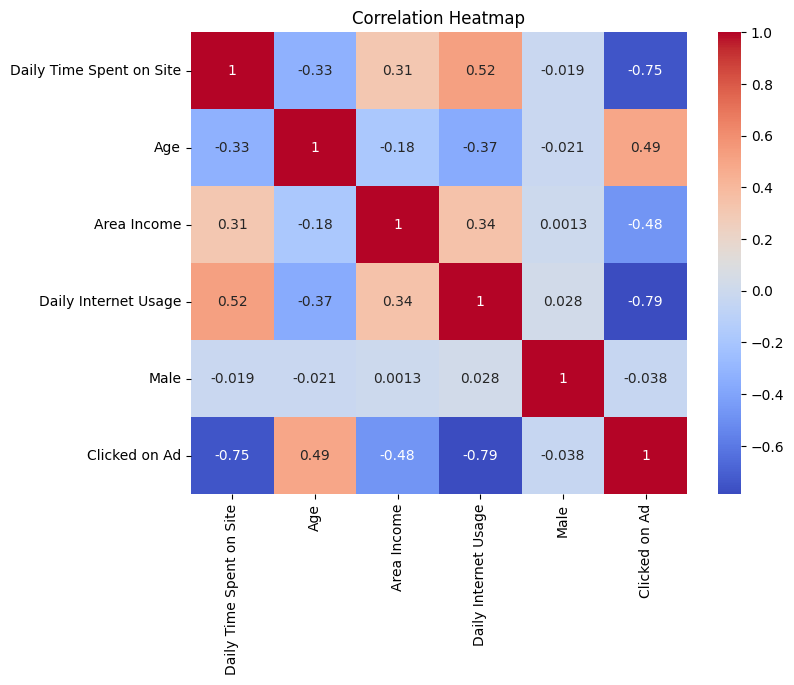

In [ ]:
#c) Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#d) Train Logistic Regression Model (80:20 Split)
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Model parameters
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Training Shape: (800, 5)
Testing Shape: (200, 5)
Intercept: [1.47571247]
Coefficients: [[-2.52553311  1.25056071 -1.63704805 -2.70402918 -0.35862744]]


In [ ]:
#e) K-Fold Cross Validation
scores = cross_val_score(model, X_scaled, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.985 0.96  0.99  0.96  0.96 ]
Average CV Score: 0.9709999999999999


In [ ]:
#f) Classification Report
y_pred = model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96        89
           1       0.97      0.95      0.96       111

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



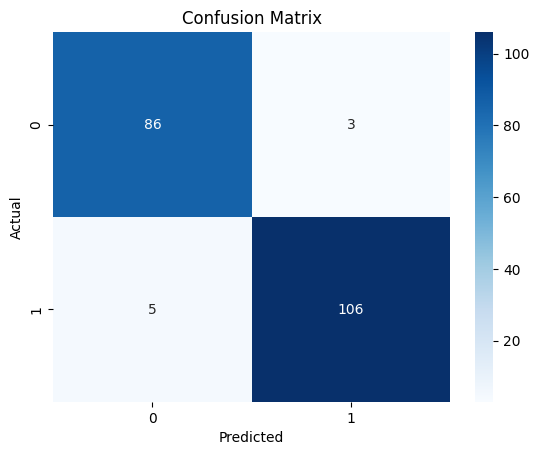

In [ ]:
#g) Confusion Matrix + ROC Curve + Precision-Recall Curve
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


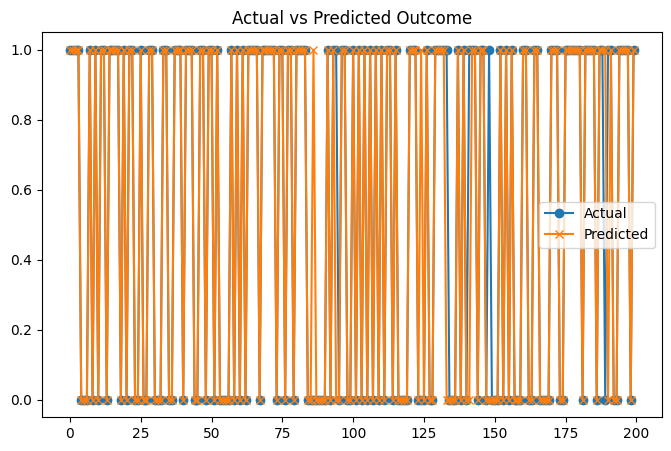

In [ ]:
#h) Predicted vs Actual Visualization
plt.figure(figsize=(8,5))
plt.plot(y_test.values, label="Actual", marker='o')
plt.plot(y_pred, label="Predicted", marker='x')
plt.legend()
plt.title("Actual vs Predicted Outcome")
plt.show()
